<h1 align="center" > Salary Classification Using Decision Tree</h1>

### Load Data

In [3]:
import pandas as pd 

In [4]:
df = pd.read_csv("salaries.csv")
df.sample(2)

,company,job,degree,salary_more_then_100k
5,google,computer programmer,masters,1
15,facebook,computer programmer,masters,1


In [5]:
df.shape

(16, 4)

### Feature Engineering: Encode Text Columns Using Label and One Hot Encoding

In [6]:
df["degree"].unique()

array(['bachelors', 'masters'], dtype=object)

In [7]:
df["degree_number"] = df.degree.map({"bachelors" : 0 , "masters" : 1 })
df.tail()

,company,job,degree,salary_more_then_100k,degree_number
11,facebook,sales executive,masters,1,1
12,facebook,business manager,bachelors,1,0
13,facebook,business manager,masters,1,1
14,facebook,computer programmer,bachelors,1,0
15,facebook,computer programmer,masters,1,1


In [8]:
df.drop("degree" , axis=1 , inplace=True)
df.head()

,company,job,salary_more_then_100k,degree_number
0,google,sales executive,0,0
1,google,sales executive,0,1
2,google,business manager,1,0
3,google,business manager,1,1
4,google,computer programmer,0,0


In [11]:
df_encoded = pd.get_dummies(df , columns = ["company" , "job"] , drop_first = True)
df_encoded.sample(2)

,salary_more_then_100k,degree_number,company_facebook,company_google,job_computer programmer,job_sales executive
14,1,0,True,False,True,False
13,1,1,True,False,False,False


### Train a classifier using a default criterian which is "gini"
We will not do train, test split because our data size is very small (16 records only). The purpose of this tutorial is to explain you DecisionTreeClassifier and also to print the decision tree (for which small dataset with less features is useful). In real life, you will almost always to train, test split

In [18]:
# split x and y values
X = df_encoded.drop("salary_more_then_100k" , axis = 1 )
y = df_encoded["salary_more_then_100k"] 

# import decision tree 
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X , y ) 

# predict y 
y_pred = model.predict(X)


### Classififcation report 

In [22]:
from sklearn.metrics import classification_report 
report = classification_report(y , y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        10

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



### confusion matrix 

<Axes: >

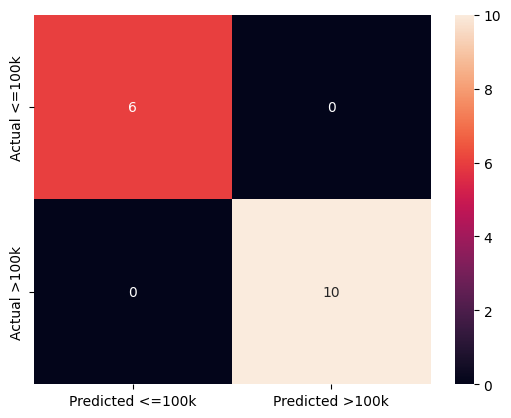

In [29]:
from sklearn.metrics import confusion_matrix 
import seaborn as sns
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm , annot=True , yticklabels = ["Actual <=100k", "Actual >100k"], xticklabels = ["Predicted <=100k", "Predicted >100k"]  )

In [32]:
from sklearn.tree import export_text
print(export_text(model, feature_names=list(X.columns)))

|--- company_facebook <= 0.50
|   |--- job_sales executive <= 0.50
|   |   |--- degree_number <= 0.50
|   |   |   |--- job_computer programmer <= 0.50
|   |   |   |   |--- company_google <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- company_google >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- job_computer programmer >  0.50
|   |   |   |   |--- class: 0
|   |   |--- degree_number >  0.50
|   |   |   |--- class: 1
|   |--- job_sales executive >  0.50
|   |   |--- class: 0
|--- company_facebook >  0.50
|   |--- class: 1



### Train a classifier using a entropy 

In [ ]:
# split x and y values
X = df_encoded.drop("salary_more_then_100k" , axis = 1 )
y = df_encoded["salary_more_then_100k"] 

# import decision tree 
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X , y ) 

# predict y 
y_pred = model.predict(X)

en_report = classification_report(y , y_pred)
print(en_report)

In [38]:
from sklearn.tree import export_text
print(export_text(model, feature_names=list(X.columns)))

|--- company_facebook <= 0.50
|   |--- job_sales executive <= 0.50
|   |   |--- degree_number <= 0.50
|   |   |   |--- job_computer programmer <= 0.50
|   |   |   |   |--- company_google <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- company_google >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- job_computer programmer >  0.50
|   |   |   |   |--- class: 0
|   |   |--- degree_number >  0.50
|   |   |   |--- class: 1
|   |--- job_sales executive >  0.50
|   |   |--- class: 0
|--- company_facebook >  0.50
|   |--- class: 1



### Now let's make some predictions

In [41]:
y_pred

array([0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [43]:
df_encoded.head(2)

,salary_more_then_100k,degree_number,company_facebook,company_google,job_computer programmer,job_sales executive
0,0,0,False,True,False,True
1,0,1,False,True,False,True


**Is salary of Google, Computer Engineer, Bachelors degree > 100 k ?**

In [46]:
model.predict([[1 , 0 , 0 ,0 , 1]])

C:\Users\123\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

**Is salary of Google, Computer Engineer, Masters degree > 100 k ?**

In [47]:
model.predict([[1 , 0 , 1 , 0 , 1]])

C:\Users\123\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])